## Install Dependencies and Load Dataset

### Subtask:
Install the necessary `kagglehub` library and then load the 'srikanthladda/house-price-prediction' dataset as a pandas DataFrame using the provided `kagglehub` code snippet. Display the first few rows to confirm successful loading.


In [ ]:
pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd

# Download the dataset
dataset_url = 'harlfoxem/housesalesprediction'

# Let kagglehub determine the path and return it
downloaded_dir = kagglehub.dataset_download(dataset_url)

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(f'{downloaded_dir}/kc_house_data.csv')

# Display the first 5 rows of the DataFrame
print(df.head())

Using Colab cache for faster access to the 'housesalesprediction' dataset.
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8       

## Data Inspection and Preprocessing

### Subtask:
Inspect the loaded dataset for missing values, data types, and distribution of key features. Based on the inspection, preprocess the data by handling missing values (e.g., imputation), encoding categorical features (e.g., one-hot encoding), and scaling numerical features if necessary. Then, split the data into training and testing sets.


In [ ]:
print('DataFrame Info:')
df.info()

print('\nStatistical Summary:')
df.describe()

print('\nMissing Values:')
df.isnull().sum()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  flo

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [ ]:
df = df.drop('id', axis=1)

# Convert 'date' to datetime and extract year and month
df['date'] = pd.to_datetime(df['date'])
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df = df.drop('date', axis=1)

print("DataFrame after dropping 'id' and processing 'date' column:")
print(df.head())

DataFrame after dropping 'id' and processing 'date' column:
      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  221900.0         3       1.00         1180      5650     1.0           0   
1  538000.0         3       2.25         2570      7242     2.0           0   
2  180000.0         2       1.00          770     10000     1.0           0   
3  604000.0         4       3.00         1960      5000     1.0           0   
4  510000.0         3       2.00         1680      8080     1.0           0   

   view  condition  grade  ...  sqft_basement  yr_built  yr_renovated  \
0     0          3      7  ...              0      1955             0   
1     0          3      7  ...            400      1951          1991   
2     0          3      6  ...              0      1933             0   
3     0          5      7  ...            910      1965             0   
4     0          3      8  ...              0      1987             0   

   zipcode      lat     lo

In [ ]:
print("Unique values for potential categorical columns:")
for col in df.columns:
    if df[col].dtype == 'int64' or df[col].dtype == 'float64':
        if col not in ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15']:
            unique_count = df[col].nunique()
            print(f"Column '{col}': {unique_count} unique values")

# Specifically check 'zipcode' as it's often treated as categorical
print(f"Column 'zipcode': {df['zipcode'].nunique()} unique values")

Unique values for potential categorical columns:
Column 'bedrooms': 13 unique values
Column 'bathrooms': 30 unique values
Column 'floors': 6 unique values
Column 'waterfront': 2 unique values
Column 'view': 5 unique values
Column 'condition': 5 unique values
Column 'grade': 12 unique values
Column 'yr_built': 116 unique values
Column 'yr_renovated': 70 unique values
Column 'zipcode': 70 unique values
Column 'zipcode': 70 unique values


In [ ]:
categorical_cols = ['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'zipcode']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df_encoded.head())

DataFrame after one-hot encoding:
      price  sqft_living  sqft_lot  sqft_above  sqft_basement  yr_built  \
0  221900.0         1180      5650        1180              0      1955   
1  538000.0         2570      7242        2170            400      1951   
2  180000.0          770     10000         770              0      1933   
3  604000.0         1960      5000        1050            910      1965   
4  510000.0         1680      8080        1680              0      1987   

   yr_renovated      lat     long  sqft_living15  ...  zipcode_98146  \
0             0  47.5112 -122.257           1340  ...          False   
1          1991  47.7210 -122.319           1690  ...          False   
2             0  47.7379 -122.233           2720  ...          False   
3             0  47.5208 -122.393           1360  ...          False   
4             0  47.6168 -122.045           1800  ...          False   

   zipcode_98148  zipcode_98155  zipcode_98166  zipcode_98168  zipcode_98177  \
0 

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (17290, 147)
X_test shape: (4323, 147)
y_train shape: (17290,)
y_test shape: (4323,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the one-hot encoded boolean columns)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns that might have been treated as categorical before one-hot encoding, but kept as int/float and are now just numerical
# These are the original numerical columns that were not one-hot encoded
# The one-hot encoded columns are of type bool, which are handled by select_dtypes(exclude=...) later

# Exclude year_built, year_renovated from scaling if they are to be treated differently
# For now, we will scale all remaining numerical columns.

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data's numerical columns and transform them
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Transform the test data's numerical columns using the *fitted* scaler
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features in X_train after scaling (first 5 rows):")
print(X_train[numerical_cols].head())
print("\nNumerical features in X_test after scaling (first 5 rows):")
print(X_test[numerical_cols].head())

Numerical features in X_train after scaling (first 5 rows):
       sqft_living  sqft_lot  sqft_above  sqft_basement  yr_built  \
6325     -0.323933 -0.043873   -0.007257      -0.656310  0.404001   
13473    -1.183653 -0.285775   -1.200048      -0.200433 -1.430565   
17614    -1.095477 -0.188293   -0.968792      -0.451165 -0.988910   
16970     0.017751 -0.187933   -0.615824       1.189993  0.200160   
20868    -0.366919 -0.343991   -0.413779       0.016109  1.219364   

       yr_renovated       lat      long  sqft_living15  sqft_lot15  
6325      -0.208294 -1.396608  0.442288       1.126073    0.013440  
13473     -0.208294 -0.060172 -0.539958      -1.046523   -0.280662  
17614     -0.208294 -0.552847 -0.860256      -1.193320   -0.178934  
16970     -0.208294 -1.193614  0.299934      -0.268498   -0.195283  
20868     -0.208294  1.040039  0.036578       0.157213   -0.082511  

Numerical features in X_test after scaling (first 5 rows):
       sqft_living  sqft_lot  sqft_above  sqft_base

## Train Regression Model

### Subtask:
Train a suitable regression model (e.g., RandomForestRegressor, Linear Regression, or Gradient Boosting Regressor) on the preprocessed training data to predict house prices.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# Train the model using the preprocessed training data
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test set using relevant regression metrics such as R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE). Print the evaluation results.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

R-squared: 0.8565
Mean Absolute Error (MAE): 72874.15
Mean Squared Error (MSE): 21691780760.11


### Training Features (X_train)

In [ ]:
display(X_train.head())

,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
6325,-0.323933,-0.043873,-0.007257,-0.656310,0.404001,-0.208294,-1.396608,0.442288,1.126073,0.013440,...,False,False,False,False,False,False,False,False,False,False
13473,-1.183653,-0.285775,-1.200048,-0.200433,-1.430565,-0.208294,-0.060172,-0.539958,-1.046523,-0.280662,...,False,False,False,False,False,False,False,False,False,False
17614,-1.095477,-0.188293,-0.968792,-0.451165,-0.988910,-0.208294,-0.552847,-0.860256,-1.193320,-0.178934,...,True,False,False,False,False,False,False,False,False,False
16970,0.017751,-0.187933,-0.615824,1.189993,0.200160,-0.208294,-1.193614,0.299934,-0.268498,-0.195283,...,False,False,False,False,False,False,False,False,False,False
20868,-0.366919,-0.343991,-0.413779,0.016109,1.219364,-0.208294,1.040039,0.036578,0.157213,-0.082511,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print('X_train DataFrame Info:')
X_train.info()

X_train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 17290 entries, 6325 to 15795
Columns: 147 entries, sqft_living to zipcode_98199
dtypes: bool(135), float64(10), int32(2)
memory usage: 3.8 MB


### Training Target Variable (y_train)

In [ ]:
display(y_train.head())

,price
6325,325000.0
13473,257000.0
17614,228500.0
16970,288000.0
20868,479000.0


In [ ]:
print('\nX_train Statistical Summary:')
X_train.describe()


X_train Statistical Summary:


,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
count,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,1.729000e+04,17290.000000,17290.000000
mean,-1.800500e-16,-2.383544e-17,-1.173279e-16,-5.270509e-17,-5.178044e-16,4.561610e-17,-1.586865e-14,3.110535e-14,-3.739699e-17,2.424640e-17,2014.321805,6.580625
std,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,0.467182,3.112576
min,-1.966219e+00,-3.676528e-01,-1.820786e+00,-6.563102e-01,-2.415795e+00,-2.082939e-01,-2.897027e+00,-2.169918e+00,-2.325125e+00,-4.386665e-01,2014.000000,1.000000
25%,-7.097046e-01,-2.522701e-01,-7.131942e-01,-6.563102e-01,-6.831492e-01,-2.082939e-01,-6.380903e-01,-8.175497e-01,-7.382489e-01,-2.776461e-01,2014.000000,4.000000
50%,-1.806459e-01,-1.853577e-01,-2.750261e-01,-6.563102e-01,1.322135e-01,-2.082939e-01,8.286219e-02,-1.200122e-01,-2.097797e-01,-1.856552e-01,2014.000000,6.000000
75%,5.137437e-01,-1.079403e-01,5.039393e-01,5.973527e-01,8.796293e-01,-2.082939e-01,8.500482e-01,6.344672e-01,5.535649e-01,-9.733376e-02,2015.000000,9.000000
max,1.099572e+01,2.960995e+01,8.610049e+00,1.033034e+01,1.491151e+00,4.848273e+00,1.569556e+00,6.399828e+00,6.205250e+00,3.118953e+01,2015.000000,12.000000


### Model Accuracy Metrics

In [ ]:
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

R-squared: 0.8565
Mean Absolute Error (MAE): 72874.15
Mean Squared Error (MSE): 21691780760.11


## Visualize Predictions

### Subtask:
Create a scatter plot comparing the actual house prices from the test set against the model's predicted house prices. Include appropriate labels and a legend for clarity.


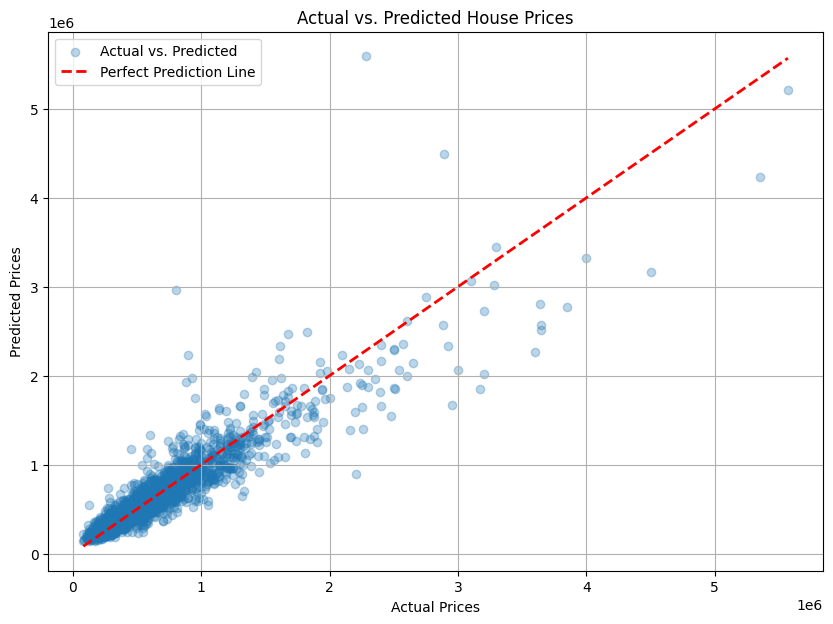

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.3, label='Actual vs. Predicted')

# Add a line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')

# Add labels and title
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# Add legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

# **Accuracy of *house* *price* *prediction* *with* *regression* is...**





In [ ]:
print(f"Model Accuracy (R-squared): {r2*100:.2f}%")

Model Accuracy (R-squared): 85.65%


## Final Task

### Subtask:
Provide a summary of the house price prediction model's performance, highlighting its accuracy, key insights from the evaluation, and any potential limitations or areas for future improvement.
